# Step 1. Text processing and chunking

In [1]:
import os
import re
import pandas as pd
import pylab as pl
import pickle
from hashlib import md5
from langchain_text_splitters import MarkdownHeaderTextSplitter

In [2]:
DATA_PATH = './data'
SPLITS_PATH = './splits'
TRUNCATE = 4000

### Text

In [3]:
with open(os.path.join(DATA_PATH, 'ЖУК В МУРАВЕЙНИКЕ.txt'), 'rt') as f:
    text = f.read()

In [4]:
text[:1000]

'Спасибо, что скачали книгу в бесплатной электронной библиотеке Royallib.ru: http://royallib.ru\n\nВсе книги автора: http://royallib.ru/author/strugatskiy_arkadiy.html\n\nЭта же книга в других форматах: http://royallib.ru/book/strugatskiy_arkadiy/guk_v_muraveynike.html\n\nПриятного чтения!\n\n\n\n\nЖУК В МУРАВЕЙНИКЕ\n\nСтояли звери\n\nОколо двери,\n\nВ них стреляли,\n\nОни умирали.\n\n\xa0\xa0\xa0\xa0(Стишок очень маленького мальчика)\n\n\n\n1 июня 78–го года\n\nСОТРУДНИК КОМКОНА–2 МАКСИМ КАММЕРЕР\n\nВ 13.17 Экселенц вызвал меня к себе. Глаз он на меня не поднял, так что я видел только его лысый череп, покрытый бледными старческими веснушками, — это означало высокую степень озабоченности и неудовольствия. Однако не моими делами, впрочем.\n\n— Садись.\n\nЯ сел.\n\n— Надо найти одного человека, — сказал он и вдруг замолчал. Надолго. Собрал кожу на лбу в сердитые складки. Фыркнул. Можно было подумать, что ему не нравились собственные слова. То ли форма, то ли содержание. Экселенц обожает 

In [5]:
text[-1000:]

'ховой гарью.\n\nИ стояла тишина.\n\nЛев Абалкин был еще жив. Пальцы его правой руки бессильно и упрямо скребли по полу, словно пытались дотянуться до лежащего в сантиметре от них серого диска детонатора. Со знаком в виде то ли стилизованной буквы «Ж», то ли японского иероглифа «сандзю».\n\nЯ шагнул к Абалкину и опустился возле него на корточки. (Экселенц каркнул мне что–то предостерегающее.) Абалкин стеклянными глазами смотрел в потолок. Лицо его было покрыто давешними серыми пятнами, рот окровавлен. Я потрогал его за плечо. Окровавленный рот шевельнулся, и он проговорил:\n\n— Стояли звери около двери…\n\n— Лева, — позвал я.\n\n— Стояли звери около двери, — повторил он настойчиво. — Стояли звери…\n\nИ тогда Майя Тойвовна Глумова закричала.\n\n\n\nСпасибо, что скачали книгу в бесплатной электронной библиотеке Royallib.ru: http://royallib.ru\n\nОставить отзыв о книге: http://royallib.ru/comment/strugatskiy_arkadiy/guk_v_muraveynike.html\n\nВсе книги автора: http://royallib.ru/author/str

### Text processing and heading marking

In [6]:
# https://royallib.com/book/strugatskiy_arkadiy/guk_v_muraveynike.html
start_plate = """Спасибо, что скачали книгу в бесплатной электронной библиотеке Royallib.ru: http://royallib.ru\n\nВсе книги автора: http://royallib.ru/author/strugatskiy_arkadiy.html\n\nЭта же книга в других форматах: http://royallib.ru/book/strugatskiy_arkadiy/guk_v_muraveynike.html\n\nПриятного чтения!\n\n\n\n\n"""
end_plate = """\n\n\n\nСпасибо, что скачали книгу в бесплатной электронной библиотеке Royallib.ru: http://royallib.ru\n\nОставить отзыв о книге: http://royallib.ru/comment/strugatskiy_arkadiy/guk_v_muraveynike.html\n\nВсе книги автора: http://royallib.ru/author/strugatskiy_arkadiy.html\n\n"""

In [7]:
txt = re.sub(rf'{start_plate}', '', text)  # drop start plate with book info
txt = re.sub(rf'{end_plate}', '', txt)  # drop end plate with book info
txt = re.sub(r'\xa0', '', txt)

txt = '# ' + txt.strip()  # mark title
txt = re.sub(r'\n{4}(\d.{3,})\n\n', r'\n\n\n\n## \1\n\n', txt)  # mark chapters
txt = re.sub(r'\n\n(\«?[А-Я]{1,}.*[А-Я]{2,})\n\n', r'\n\n### \1\n\n', txt)  # mark chapter sections
txt = re.sub(r'\n\n([А-Я—])', r'\n\1', txt)  # remove empty lines
md_text = txt

In [8]:
md_text[:1000]

'# ЖУК В МУРАВЕЙНИКЕ\nСтояли звери\nОколо двери,\nВ них стреляли,\nОни умирали.\n\n(Стишок очень маленького мальчика)\n\n\n\n## 1 июня 78–го года\n\n### СОТРУДНИК КОМКОНА–2 МАКСИМ КАММЕРЕР\nВ 13.17 Экселенц вызвал меня к себе. Глаз он на меня не поднял, так что я видел только его лысый череп, покрытый бледными старческими веснушками, — это означало высокую степень озабоченности и неудовольствия. Однако не моими делами, впрочем.\n— Садись.\nЯ сел.\n— Надо найти одного человека, — сказал он и вдруг замолчал. Надолго. Собрал кожу на лбу в сердитые складки. Фыркнул. Можно было подумать, что ему не нравились собственные слова. То ли форма, то ли содержание. Экселенц обожает абсолютную точность формулировок.\n— Кого именно? — спросил я, чтобы вывести его из филологического ступора.\n— Льва Вячеславовича Абалкина. Прогрессора. Отбыл позавчера на Землю с Полярной станции Саракша. На Земле не зарегистрировался. Надо его найти.\nОн снова замолчал и тут впервые поднял на меня свои круглые, неесте

In [9]:
DIALOG_STRING_MARKER = '—'
def splitter(text:str, max_size:int) -> str:
    result_text = ''
    paragraph_list = text.split(sep='###')
    print(f'Third-level chunks: {len(paragraph_list)}')

    splitted_paragraph_list = []
    splits_count = 0
    for paragraph in paragraph_list:
        if len(paragraph) > max_size:
            strings_list = paragraph.split('\n')
            buffer = ''
            splitted_strings_list = []
            for string in strings_list:
                buffer += string
                if len(buffer) > max_size and not string.startswith(DIALOG_STRING_MARKER):
                    string = '\n###\n' + string
                    splits_count += 1
                    buffer = ''
                splitted_strings_list.append(string)
            paragraph = '\n'.join(splitted_strings_list)
        splitted_paragraph_list.append(paragraph)
       
    result_text = '###'.join(splitted_paragraph_list)
    print(f'New splits: {splits_count}')
    return result_text

md_text = splitter(text=md_text, max_size=TRUNCATE)

Third-level chunks: 31
New splits: 67


#### Naming third-level headings

In [10]:
# Header 3 naming
md_text = re.sub(r'\n\n###\n(.{5,25}[ \,\.\-\?])', r'\n\n### \1\n\1', md_text)

# Clean
clear_headers_text = ''
md_text = md_text.split('\n')
for string in md_text:
    if string.startswith('###'):
        string = re.sub(r'[\—\,\;\:\?\!]', '', string)
        string = re.sub(r' {2,}', ' ', string)
        if not re.search(r'[А-Я]{2,}$', string):
            string = string.strip() + '...'
    clear_headers_text += f'{string.strip()}\n'
md_text = clear_headers_text

#### Saving and restoring Markdown text

In [11]:
with open(os.path.join(DATA_PATH, 'beetle_in_anthill.md'), 'wt',  encoding='utf-8') as f:
    f.write(md_text)

In [12]:
with open(os.path.join(DATA_PATH, 'beetle_in_anthill.md'), 'rt',  encoding='utf-8') as f:
    md_text = f.read()

### Markdown splitting

In [13]:
headers_to_split_on = [
    ("#", "title"),
    ("##", "chapter"),
    ("###", "section"),
]
markdown_splitter = MarkdownHeaderTextSplitter(headers_to_split_on)
splits = markdown_splitter.split_text(md_text)

In [14]:
len(splits)

99

#### Add metadata to content and save

In [15]:
for s in splits:
    chapter = s.metadata.get('chapter')
    section = s.metadata.get('section', '')
    if not re.search(r'[А-Я]{3,}', section):
        section = ''
    else:
        section = section.strip() + '\n\n'
    text_cut = s.page_content[:500]
    s.page_content = f'{chapter.strip() if chapter else ""}\n\n{section if section else ""}{s.page_content}'
    s.metadata['id'] = md5(text_cut.encode()).hexdigest()
    s.metadata['size'] = len(s.page_content)
    s.metadata['collection'] = 'beetle_in_anthill'

In [16]:
splits[0]

Document(metadata={'title': 'ЖУК В МУРАВЕЙНИКЕ', 'id': '05fa57cd9e07c85d87b417cbe1fcd1c8', 'size': 93, 'collection': 'beetle_in_anthill'}, page_content='\n\nСтояли звери\nОколо двери,\nВ них стреляли,\nОни умирали.  \n(Стишок очень маленького мальчика)')

In [17]:
with open(os.path.join(SPLITS_PATH, 'splits.pkl'), 'wb') as f:
    pickle.dump(splits, f)

### Analysis of the distribution of chunks lengths

In [18]:
splits_size = []
for s in splits:
    splits_size.append(len(s.page_content))

In [19]:
# Before truncating and gluing:
# min 93
# max 36330

# After truncating and gluing
print('min', min(splits_size))
print('max', max(splits_size))

min 33
max 5501


In [20]:
df = pd.DataFrame(splits_size, columns=['size'])
df.sort_values(by='size', ascending=True).head(5)

,size
35,33
0,93
7,360
52,806
65,1043


In [21]:
df.sort_values(by='size', ascending=False).head(5)

,size
14,5501
91,5416
66,5302
58,5128
54,5048


In [22]:
splits[7]

Document(metadata={'title': 'ЖУК В МУРАВЕЙНИКЕ', 'chapter': '01.06. — 13.01. СЛОН — СТРАННИКУ.', 'section': 'И тут же я понял еще одну...', 'id': '332c2c4dc2f1141827c79cdab488b978', 'size': 360, 'collection': 'beetle_in_anthill'}, page_content='01.06. — 13.01. СЛОН — СТРАННИКУ.\n\nИ тут же я понял еще одну вещь. Вернее, не понял, а почувствовал. А еще точнее — заподозрил. Вся эта громоздкая папка, все это обилие бумаги, вся эта пожелтевшая писанина ничего не дадут мне, кроме, может быть, еще нескольких имен и огромного количества новых вопросов, опять–таки не имеющих никакого отношения к вопросу КАК.')

In [23]:
# pl.title("Histogram of Сhunk sizes before additional splitting")
# pl.xlabel("Size in symbols")
# pl.ylabel("Amt")
# df['size'].hist(figsize=(7, 4), bins=10)
# pl.savefig('hist_before.png')

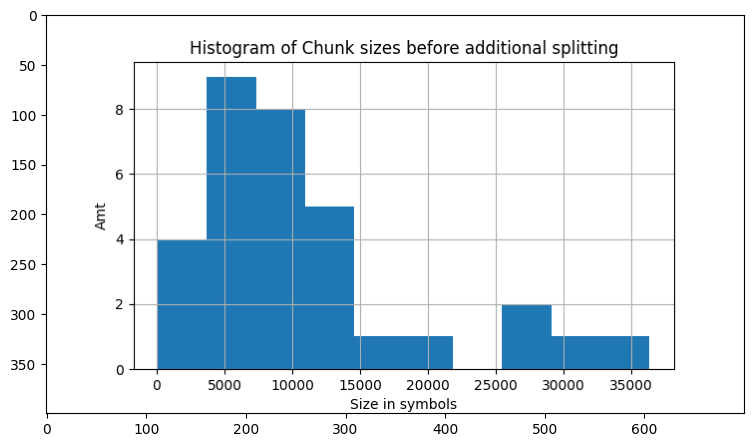

In [24]:
img = pl.imread('hist_before.png')
fig, ax = pl.subplots(figsize=(9, 6))
pl.imshow(img)
pl.show()

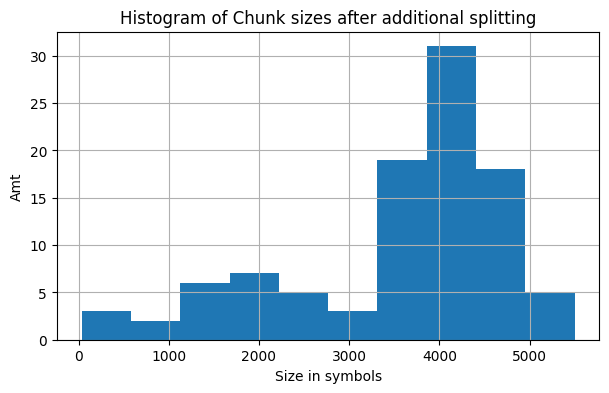

In [25]:
pl.title("Histogram of Сhunk sizes after additional splitting")
pl.xlabel("Size in symbols")
pl.ylabel("Amt")
df['size'].hist(figsize=(7, 4))
pl.savefig('hist_after.png')